In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/Heart disease dataset/raw_merged_heart_dataset.csv"

df = pd.read_csv(file_path)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df_eda = df.copy()

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2181 entries, 0 to 2180
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2181 non-null   int64  
 1   sex       2181 non-null   int64  
 2   cp        2181 non-null   int64  
 3   trestbps  2181 non-null   object 
 4   chol      2181 non-null   object 
 5   fbs       2181 non-null   object 
 6   restecg   2181 non-null   object 
 7   thalachh  2181 non-null   object 
 8   exang     2181 non-null   object 
 9   oldpeak   2181 non-null   float64
 10  slope     2181 non-null   object 
 11  ca        2181 non-null   object 
 12  thal      2181 non-null   object 
 13  target    2181 non-null   int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 238.7+ KB


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalachh,0
exang,0
oldpeak,0


In [ ]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in df_eda.columns:
    df_eda[col] = pd.to_numeric(df_eda[col], errors='coerce')

In [ ]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

for col in df_eda.columns:
    if df_eda[col].isnull().sum() > 0:
        df_eda[col].fillna(df_eda[col].median(), inplace=True)

/tmp/ipykernel_1823/4096518776.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_1823/4096518776.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [ ]:
df_eda['sex'] = df_eda['sex'].map({0: 'Female', 1: 'Male'})
df_eda['target'] = df_eda['target'].map({0: 'No Disease', 1: 'Disease'})

EDA

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(6,4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

/tmp/ipykernel_1823/163495071.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df_eda, palette='Set2')


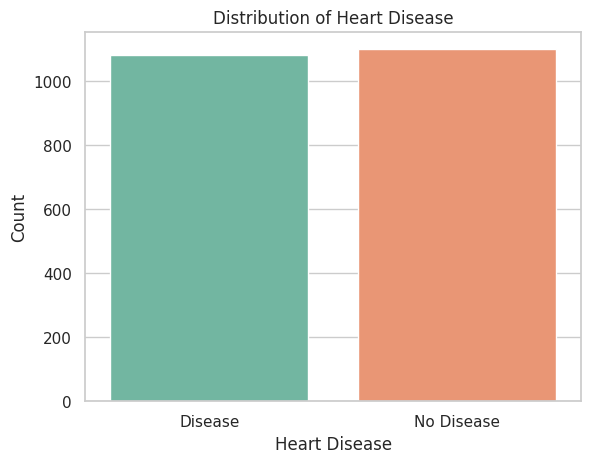

In [ ]:
sns.countplot(x='target', data=df_eda, palette='Set2')
plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

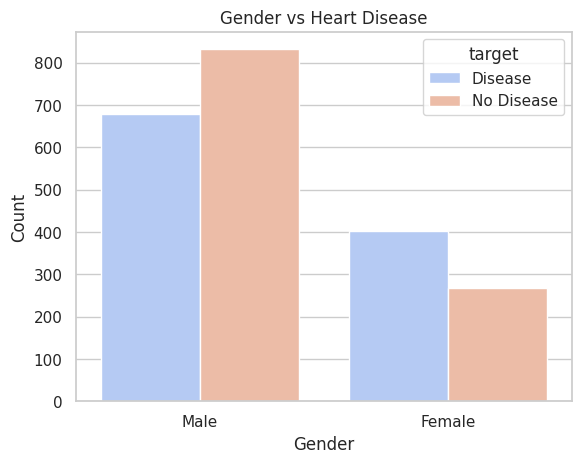

In [ ]:
sns.countplot(x='sex', hue='target', data=df_eda, palette='coolwarm')
plt.title("Gender vs Heart Disease")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

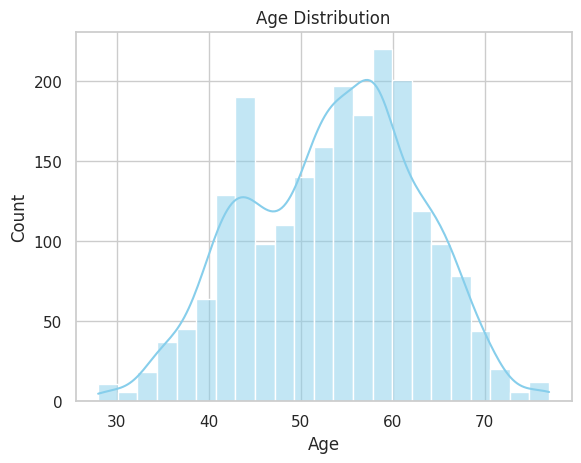

In [ ]:
sns.histplot(df_eda['age'], kde=True, color='skyblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

/tmp/ipykernel_1823/991863631.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='age', data=df_eda, palette='Set3')


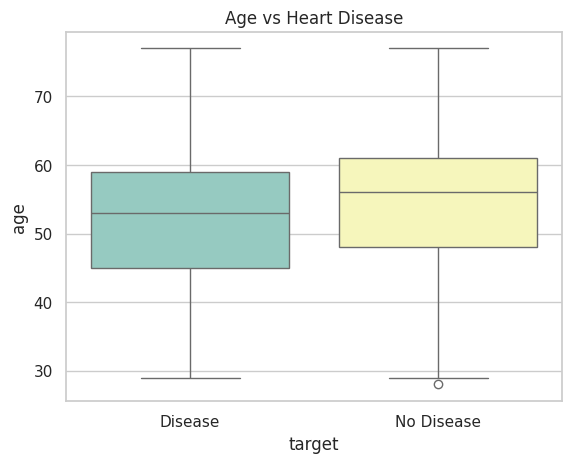

In [ ]:
sns.boxplot(x='target', y='age', data=df_eda, palette='Set3')
plt.title("Age vs Heart Disease")
plt.show()

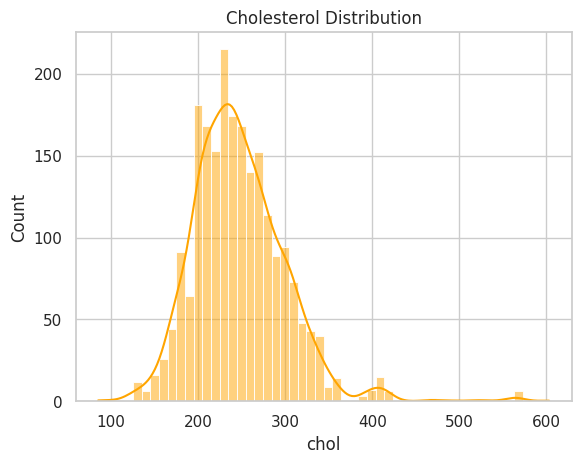

In [ ]:
sns.histplot(df_eda['chol'], kde=True, color='orange')
plt.title("Cholesterol Distribution")
plt.show()

/tmp/ipykernel_1823/981551357.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='trestbps', data=df_eda, palette='pastel')


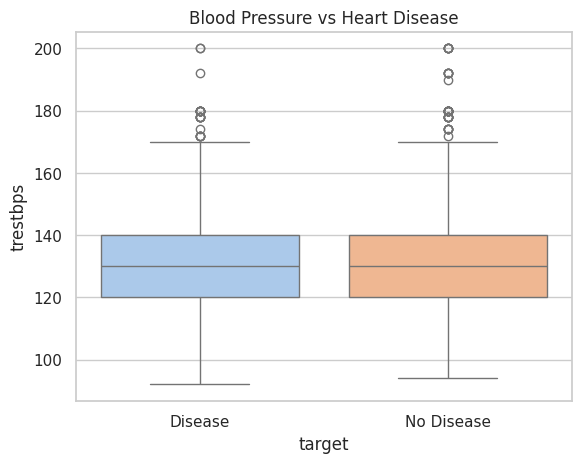

In [ ]:
sns.boxplot(x='target', y='trestbps', data=df_eda, palette='pastel')
plt.title("Blood Pressure vs Heart Disease")
plt.show()

/tmp/ipykernel_1823/494590361.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='thalachh', data=df_eda, palette='cool')


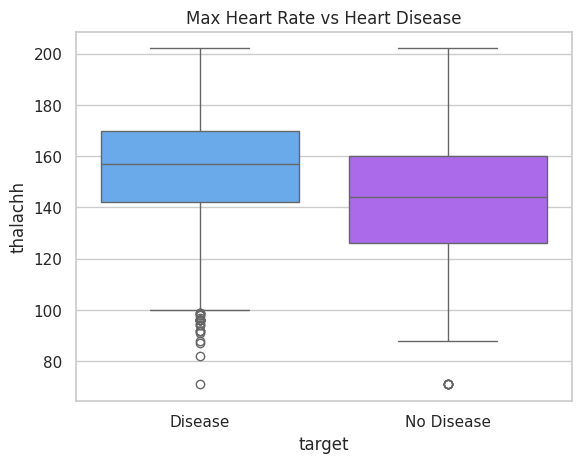

In [ ]:
sns.boxplot(x='target', y='thalachh', data=df_eda, palette='cool')
plt.title("Max Heart Rate vs Heart Disease")
plt.show()

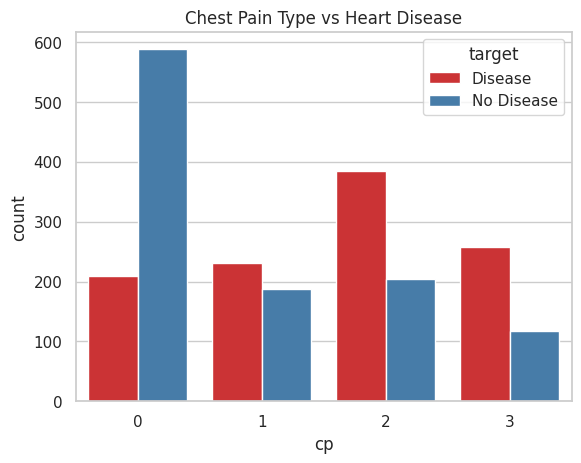

In [ ]:
sns.countplot(x='cp', hue='target', data=df_eda, palette='Set1')
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

/tmp/ipykernel_1823/3970441837.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='oldpeak', data=df_eda, palette='Set2')


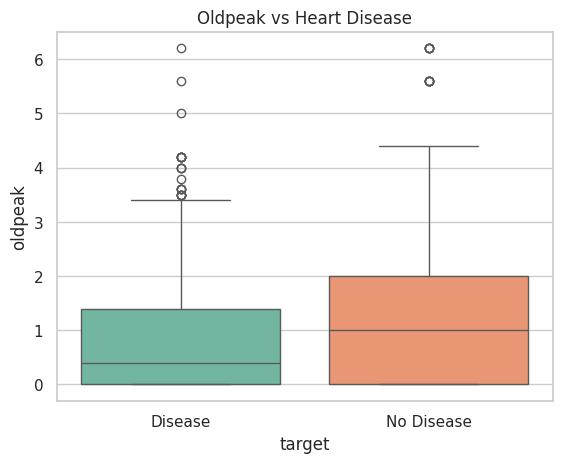

In [ ]:
sns.boxplot(x='target', y='oldpeak', data=df_eda, palette='Set2')
plt.title("Oldpeak vs Heart Disease")
plt.show()

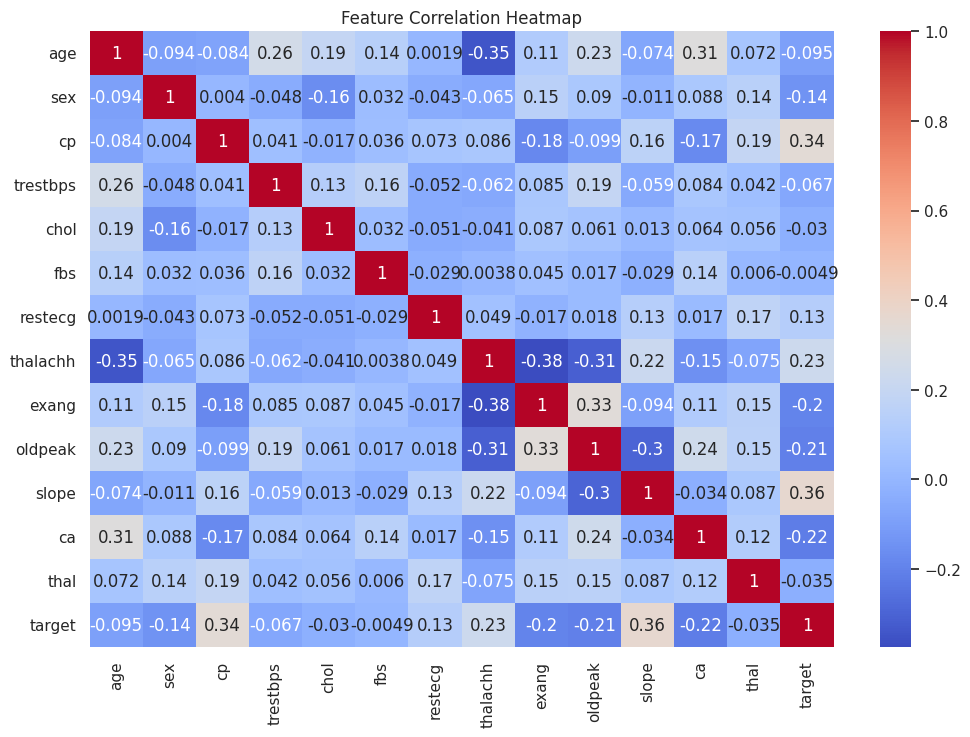

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

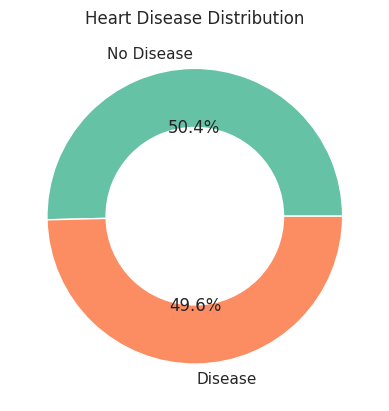

In [ ]:
df_eda['target'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['#66c2a5','#fc8d62'],
    wedgeprops=dict(width=0.4)
)

plt.title("Heart Disease Distribution")
plt.ylabel('')
plt.show()

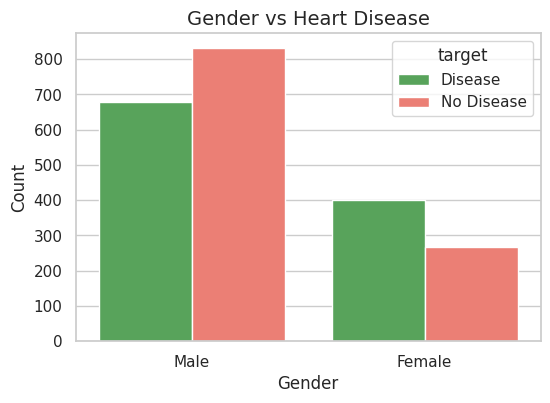

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='sex',
    hue='target',
    data=df_eda,
    palette=['#4CAF50', '#FF6F61']
)

plt.title("Gender vs Heart Disease", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

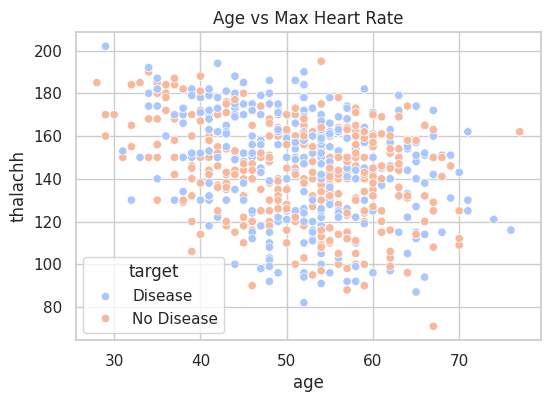

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='age',
    y='thalachh',
    hue='target',
    data=df_eda,
    palette='coolwarm'
)

plt.title("Age vs Max Heart Rate")
plt.show()

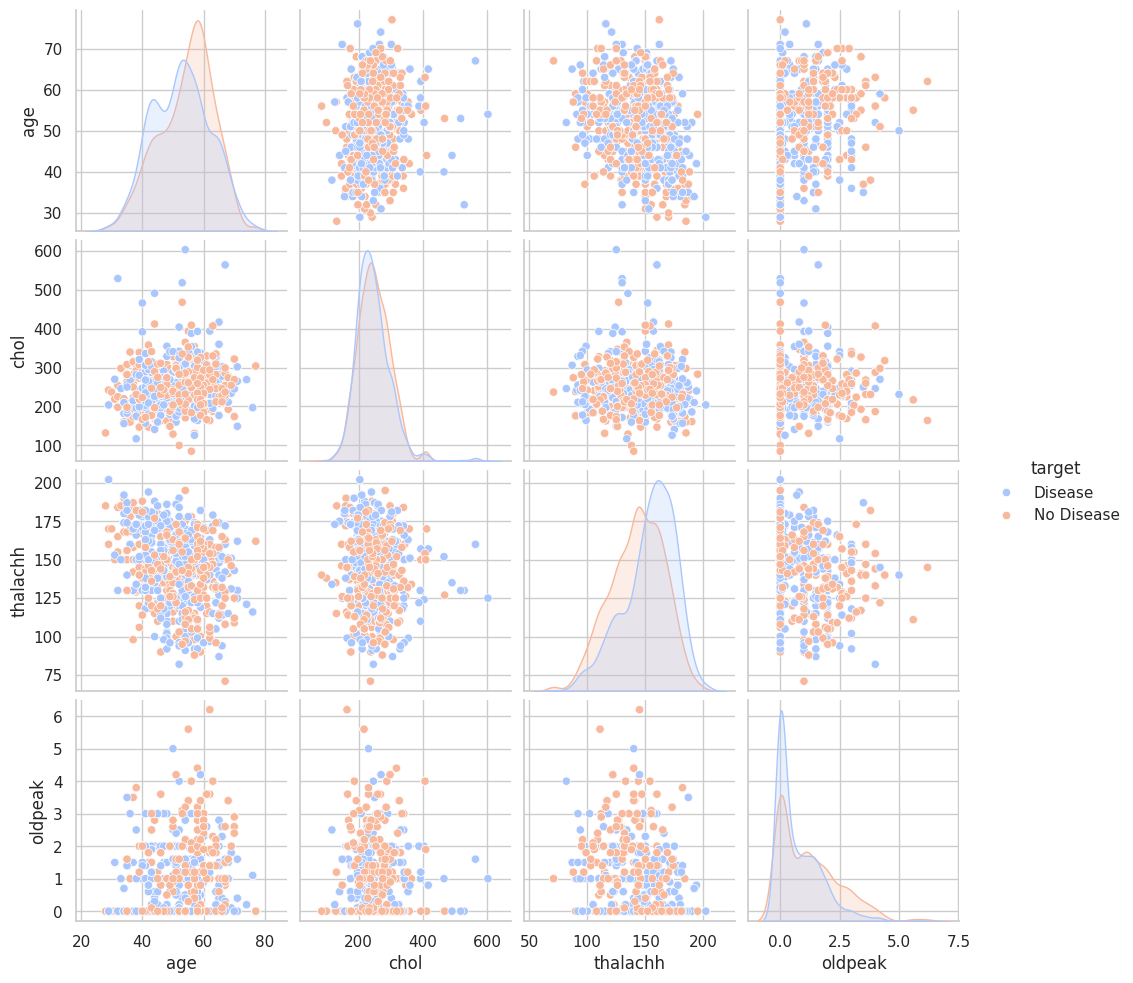

In [ ]:
sns.pairplot(
    df_eda[['age','chol','thalachh','oldpeak','target']],
    hue='target',
    palette='coolwarm'
)

plt.show()

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

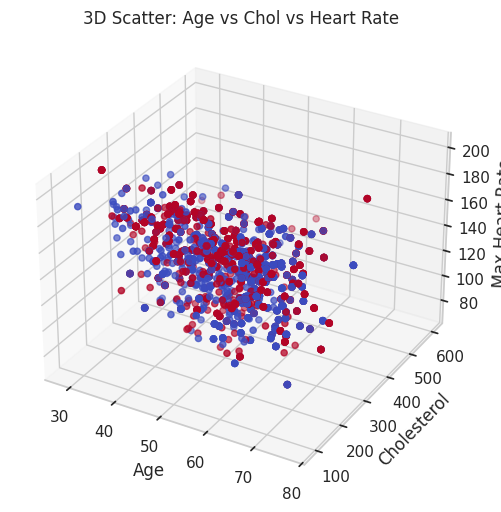

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['age'],
    df['chol'],
    df['thalachh'],
    c=df['target'],
    cmap='coolwarm'
)

ax.set_xlabel('Age')
ax.set_ylabel('Cholesterol')
ax.set_zlabel('Max Heart Rate')

plt.title("3D Scatter: Age vs Chol vs Heart Rate")
plt.show()
plt.tight_layout()

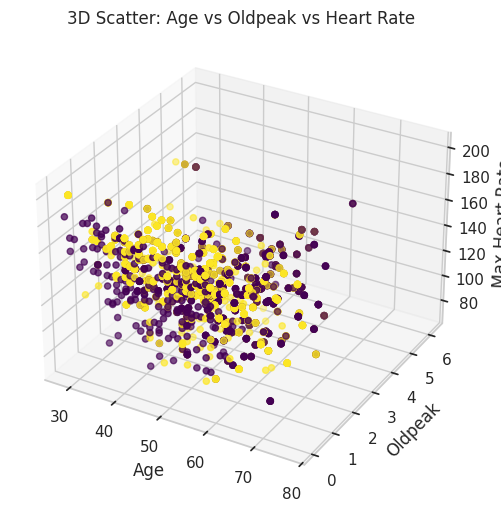

In [ ]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['age'],
    df['oldpeak'],
    df['thalachh'],
    c=df['target'],
    cmap='viridis'
)

ax.set_xlabel('Age')
ax.set_ylabel('Oldpeak')
ax.set_zlabel('Max Heart Rate')

plt.title("3D Scatter: Age vs Oldpeak vs Heart Rate")
plt.show()

/tmp/ipykernel_1823/1801887223.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


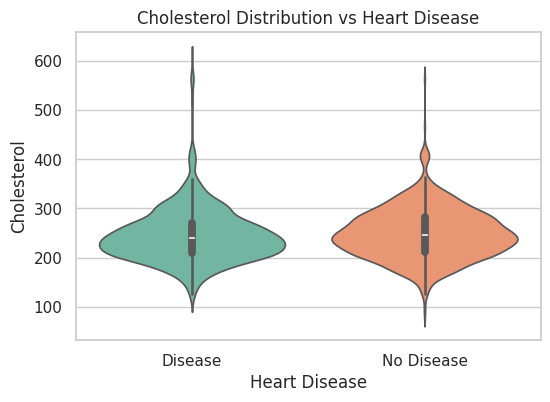

In [ ]:
plt.figure(figsize=(6,4))

sns.violinplot(
    x='target',
    y='chol',
    data=df_eda,
    palette=['#66c2a5','#fc8d62']
)

plt.title("Cholesterol Distribution vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol")

plt.show()

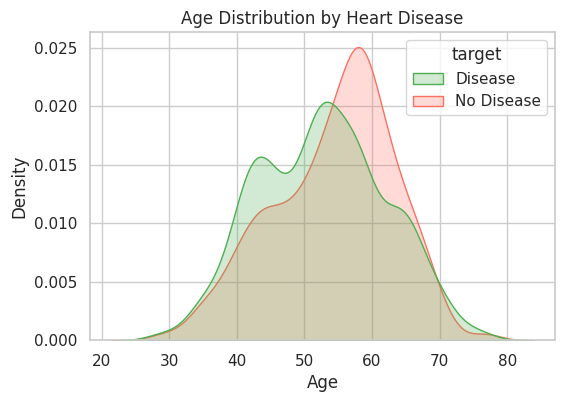

In [ ]:
plt.figure(figsize=(6,4))

sns.kdeplot(
    data=df_eda,
    x='age',
    hue='target',
    fill=True,
    palette=['#4CAF50', '#FF6F61']
)

plt.title("Age Distribution by Heart Disease")
plt.xlabel("Age")
plt.ylabel("Density")

plt.show()

Models

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(1744, 13)
(437, 13)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

LogisticRegression()

In [ ]:
lr_pred = lr.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7528604118993135


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.78      0.70      0.74       217
           1       0.73      0.81      0.77       220

    accuracy                           0.75       437
   macro avg       0.76      0.75      0.75       437
weighted avg       0.76      0.75      0.75       437



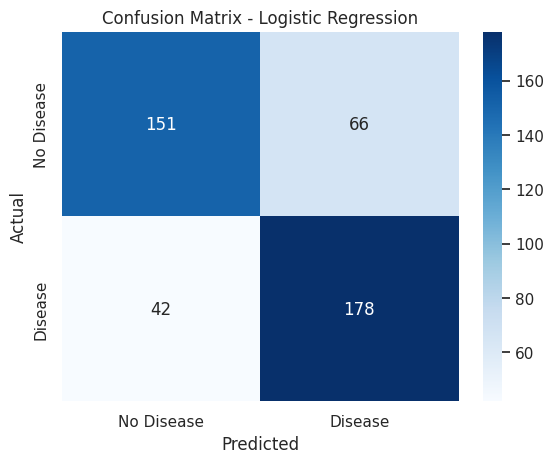

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Disease','Disease'],
    yticklabels=['No Disease','Disease']
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

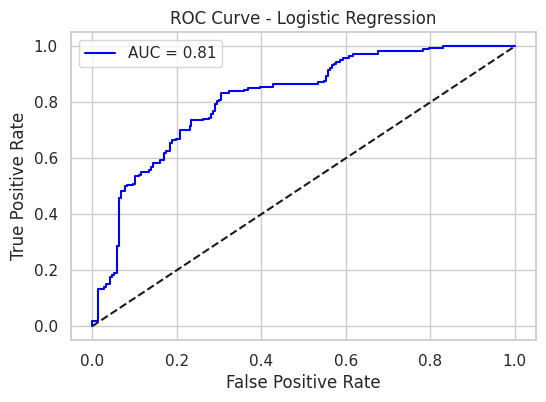

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob_lr = lr.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='blue', label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
dt_pred = dt.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.9450800915331807


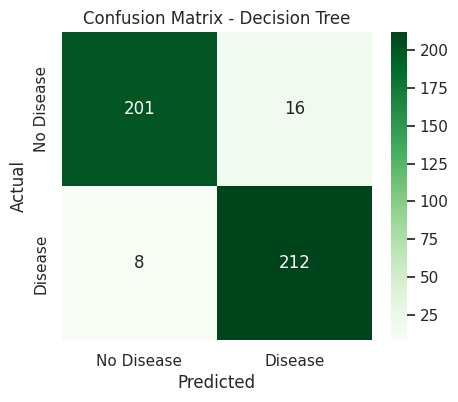

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Disease','Disease'],
    yticklabels=['No Disease','Disease']
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

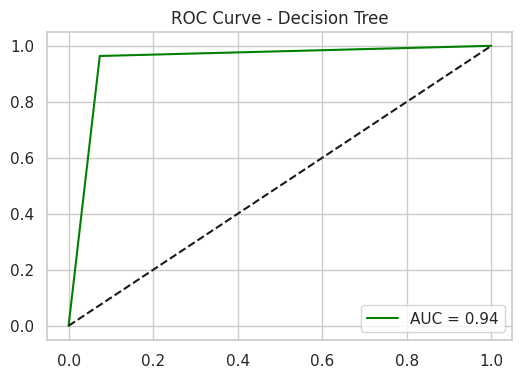

In [ ]:
y_prob_dt = dt.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='green', label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.931350114416476


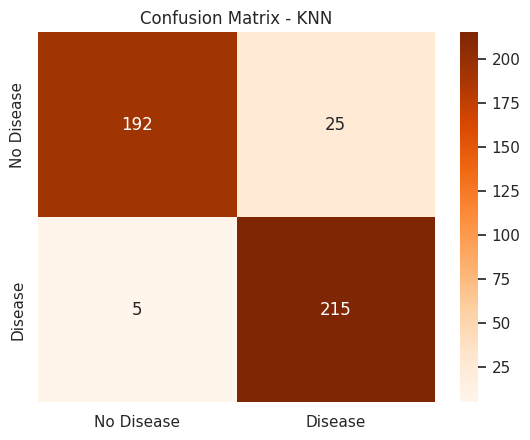

In [ ]:
cm_knn = confusion_matrix(y_test, knn_pred)

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['No Disease','Disease'],
    yticklabels=['No Disease','Disease']
)

plt.title("Confusion Matrix - KNN")
plt.show()

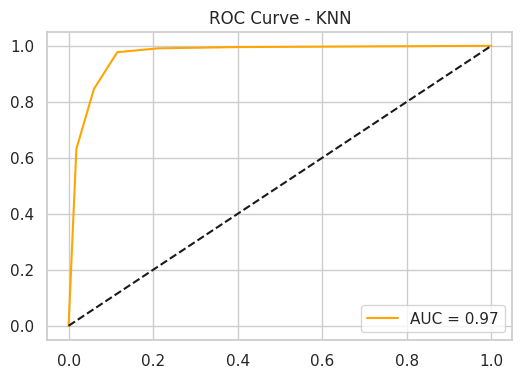

In [ ]:
y_prob_knn = knn.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob_knn)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='orange', label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve - KNN")
plt.legend()
plt.show()

Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC

svm = SVC(probability=True)

svm.fit(X_train, y_train)

SVC(probability=True)

In [ ]:
svm_pred = svm.predict(X_test)

In [ ]:
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.9038901601830663


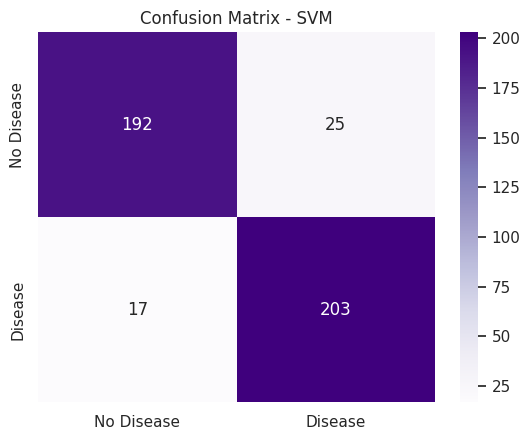

In [ ]:
cm_svm = confusion_matrix(y_test, svm_pred)

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Disease','Disease'],
    yticklabels=['No Disease','Disease']
)

plt.title("Confusion Matrix - SVM")
plt.show()

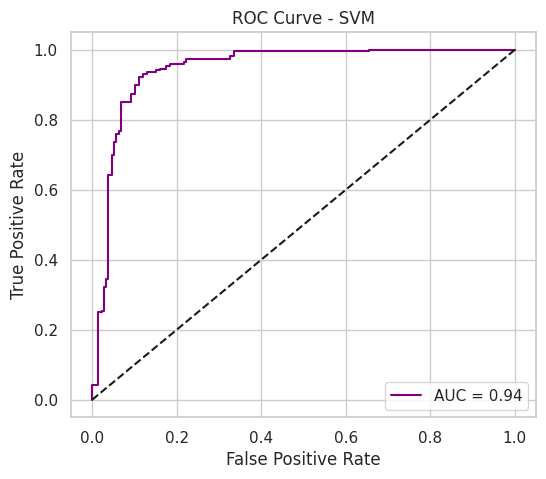

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob_svm = svm.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_svm)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, color='purple', label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')

plt.title("ROC Curve - SVM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

## ENSEMBLE LEARNING

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
rf_pred = rf.predict(X_test)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

rf_pred_tuned = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Tuned Random Forest Accuracy:", accuracy_score(y_test, rf_pred_tuned))

Tuned Random Forest Accuracy: 0.9565217391304348


In [ ]:
print("Original RF Accuracy:", accuracy_score(y_test, rf_pred))
print("Tuned RF Accuracy:", accuracy_score(y_test, rf_pred_tuned))

Original RF Accuracy: 0.9519450800915332
Tuned RF Accuracy: 0.9565217391304348


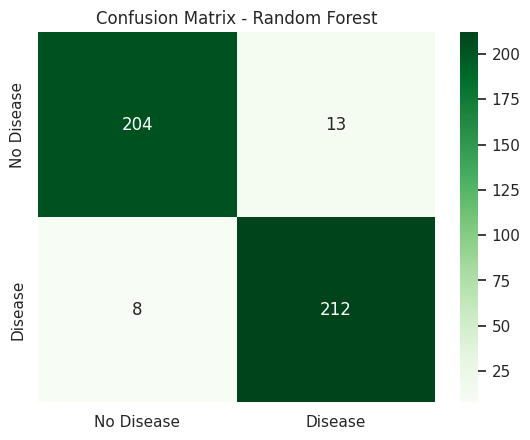

In [ ]:
cm_rf = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Disease','Disease'],
    yticklabels=['No Disease','Disease']
)

plt.title("Confusion Matrix - Random Forest")
plt.show()

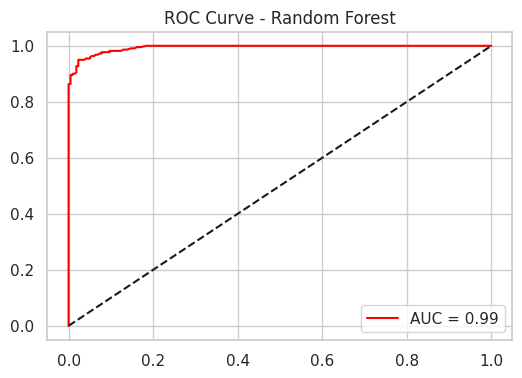

In [ ]:
y_prob_rf = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='red', label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

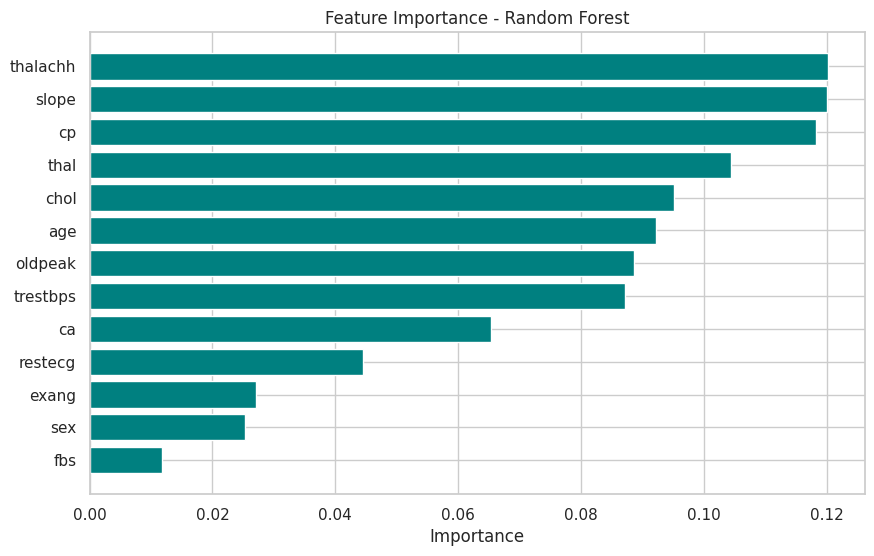

In [ ]:
import numpy as np

importances = rf.feature_importances_
features = X.columns

indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.barh(features[indices], importances[indices], color='teal')

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

XGBoost

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:26:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb.predict(X_test)

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid_xgb = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

grid_xgb = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    param_grid_xgb,
    cv=3,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

xgb_pred_tuned = best_xgb.predict(X_test)

from sklearn.metrics import accuracy_score
print("Tuned XGBoost Accuracy:", accuracy_score(y_test, xgb_pred_tuned))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:26:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Tuned XGBoost Accuracy: 0.9473684210526315


In [ ]:
print("Original XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("Tuned XGBoost Accuracy:", accuracy_score(y_test, xgb_pred_tuned))

Original XGBoost Accuracy: 0.9473684210526315
Tuned XGBoost Accuracy: 0.9473684210526315


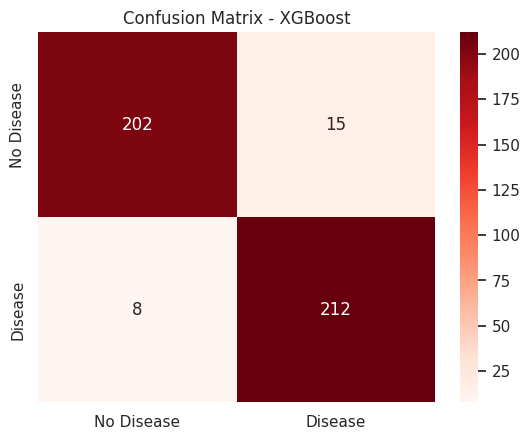

In [ ]:
cm_xgb = confusion_matrix(y_test, xgb_pred)

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['No Disease','Disease'],
    yticklabels=['No Disease','Disease']
)

plt.title("Confusion Matrix - XGBoost")
plt.show()

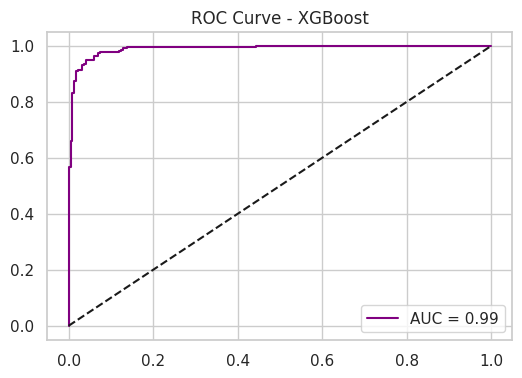

In [ ]:
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='purple', label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

# **Now Finally we implement Voting Classifier (Combined Model)**

In [ ]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf),
        ('xgb', xgb)
    ],
    voting='soft'
)

In [ ]:
voting.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:28:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_w...
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [ ]:
voting_pred = voting.predict(X_test)

In [ ]:
from sklearn.ensemble import VotingClassifier

voting_final = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', best_rf),
        ('xgb', best_xgb)
    ],
    voting='soft'
)

voting_final.fit(X_train, y_train)

voting_pred_final = voting_final.predict(X_test)

from sklearn.metrics import accuracy_score
print("Final Voting Accuracy:", accuracy_score(y_test, voting_pred_final))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:28:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Final Voting Accuracy: 0.9473684210526315


In [ ]:
print("Old Voting Accuracy:", accuracy_score(y_test, voting_pred))
print("Final Voting Accuracy:", accuracy_score(y_test, voting_pred_final))

Old Voting Accuracy: 0.9496567505720824
Final Voting Accuracy: 0.9473684210526315


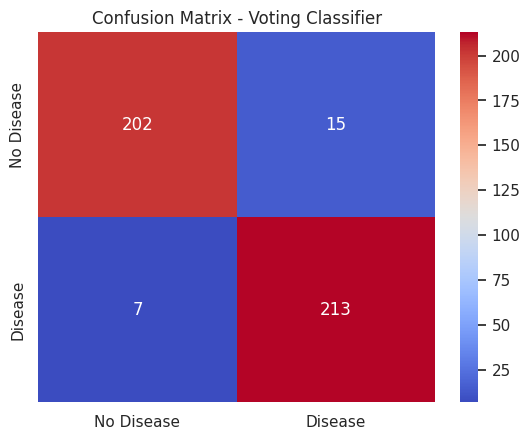

In [ ]:
cm_vote = confusion_matrix(y_test, voting_pred)

sns.heatmap(
    cm_vote,
    annot=True,
    fmt='d',
    cmap='coolwarm',
    xticklabels=['No Disease','Disease'],
    yticklabels=['No Disease','Disease']
)

plt.title("Confusion Matrix - Voting Classifier")
plt.show()

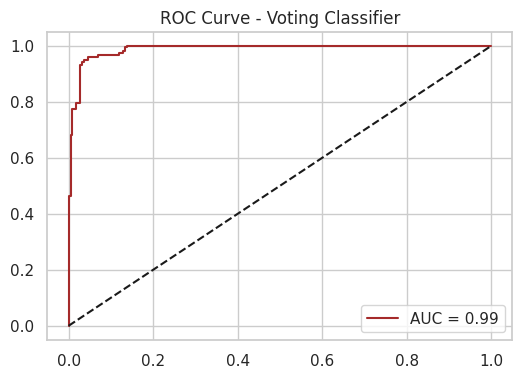

In [ ]:
y_prob_vote = voting.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob_vote)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='brown', label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve - Voting Classifier")
plt.legend()
plt.show()

# **Overall comparision**

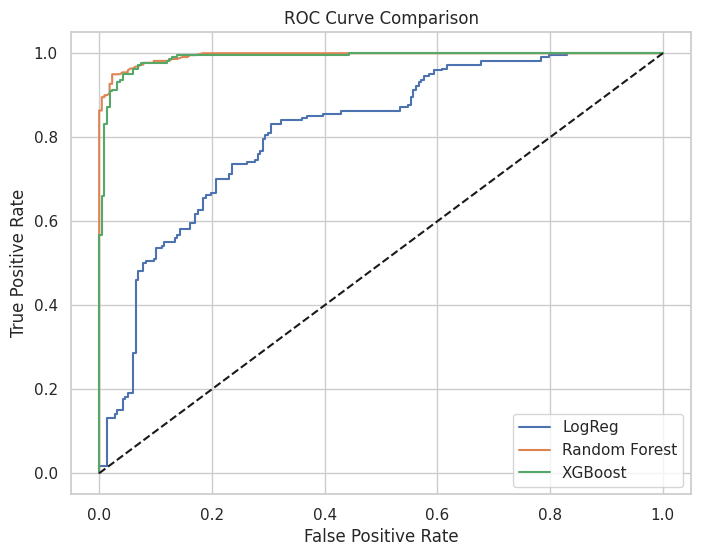

In [ ]:
from sklearn.metrics import roc_curve, auc

models = {
    "LogReg": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

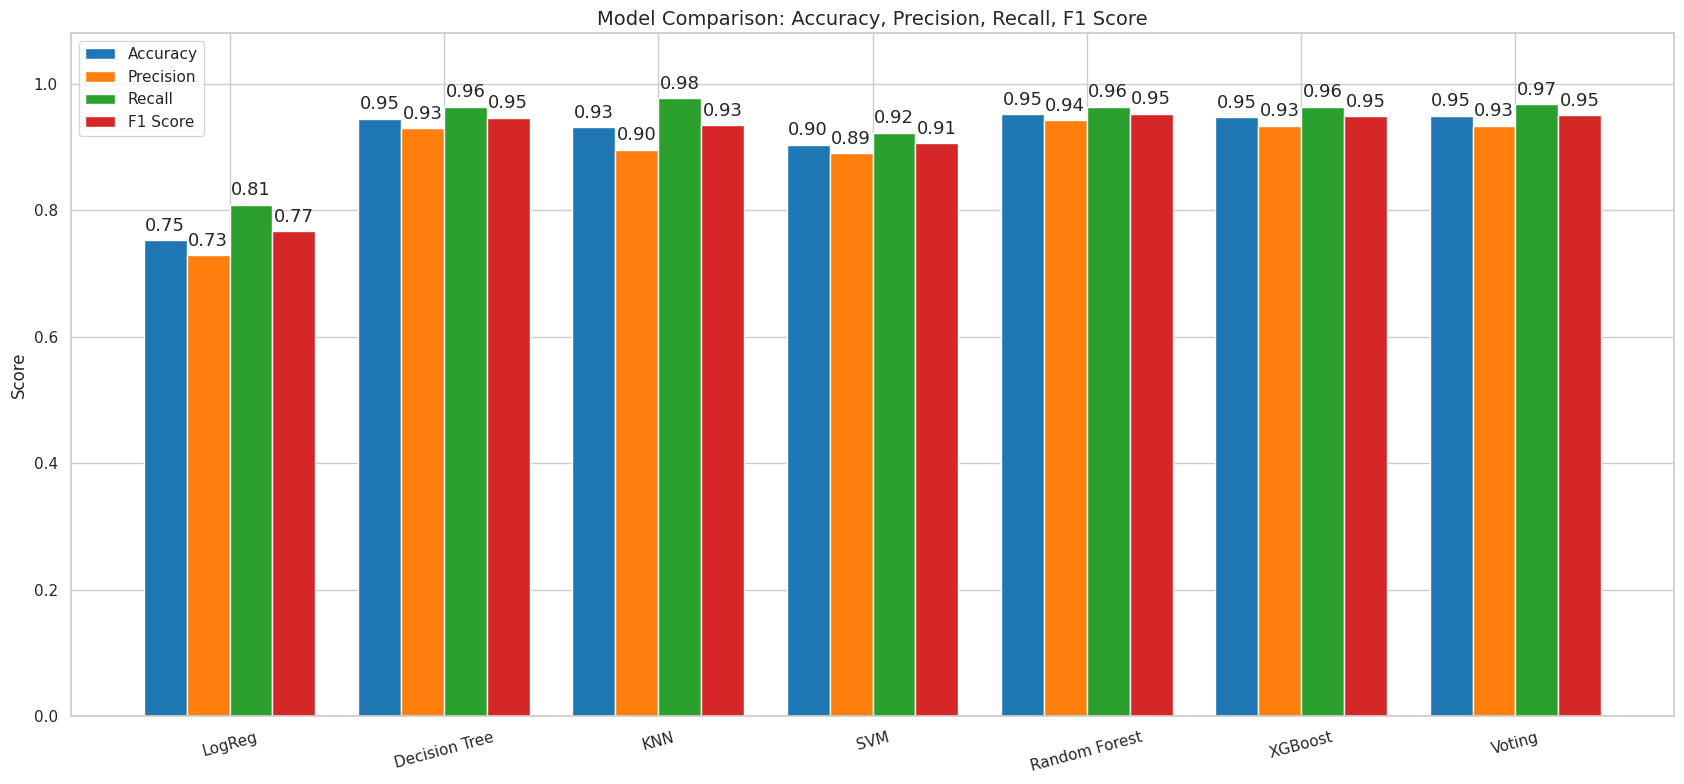

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = ['LogReg', 'Decision Tree', 'KNN', 'SVM', 'Random Forest', 'XGBoost', 'Voting']

accuracy = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, knn_pred),
    accuracy_score(y_test, svm_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, xgb_pred),
    accuracy_score(y_test, voting_pred)
]

precision = [
    precision_score(y_test, lr_pred),
    precision_score(y_test, dt_pred),
    precision_score(y_test, knn_pred),
    precision_score(y_test, svm_pred),
    precision_score(y_test, rf_pred),
    precision_score(y_test, xgb_pred),
    precision_score(y_test, voting_pred)
]

recall = [
    recall_score(y_test, lr_pred),
    recall_score(y_test, dt_pred),
    recall_score(y_test, knn_pred),
    recall_score(y_test, svm_pred),
    recall_score(y_test, rf_pred),
    recall_score(y_test, xgb_pred),
    recall_score(y_test, voting_pred)
]

f1 = [
    f1_score(y_test, lr_pred),
    f1_score(y_test, dt_pred),
    f1_score(y_test, knn_pred),
    f1_score(y_test, svm_pred),
    f1_score(y_test, rf_pred),
    f1_score(y_test, xgb_pred),
    f1_score(y_test, voting_pred)
]

x = np.arange(len(models)) * 1.5
width = 0.30

plt.figure(figsize=(17,8))

bars1 = plt.bar(x - 1.5*width, accuracy, width, label='Accuracy', color='#1f77b4')
bars2 = plt.bar(x - 0.5*width, precision, width, label='Precision', color='#ff7f0e')
bars3 = plt.bar(x + 0.5*width, recall, width, label='Recall', color='#2ca02c')
bars4 = plt.bar(x + 1.5*width, f1, width, label='F1 Score', color='#d62728')

plt.xticks(x, models, rotation=15, fontsize=11)
plt.ylabel("Score", fontsize=12)
plt.title("Model Comparison: Accuracy, Precision, Recall, F1 Score", fontsize=14)
plt.ylim(0, 1.08)

for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.015,
            f'{height:.2f}',
            ha='center',
            fontsize=13
        )

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()